# Wang 2016 Classifier comparison

This Jupyter Notebook replicates the signal processing described in the <mark>IEEE EMBC 2026</mark> publication to process the [Wang 2016](https://ieeexplore.ieee.org/abstract/document/7740878) dataset classifier comparison. This dataset can be fully downloaded from [MOABB](https://moabb.neurotechx.com/docs/generated/moabb.datasets.Wang2016.html). Note that each code cell might have some configuration parameters to be define at the top of the respective cell. Thus, it is recommended to run each cell individually, not the full Notebook.

## Import libraries

In [3]:
# Default libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import sys
sys.path.append("..")

from moabb.datasets import Wang2016

# Import custom libraries
from functions import data_tools
from FeatureExtractorSSVEP import FeatureExtractorCCA as CCA
from FeatureExtractorSSVEP import FeatureExtractorMSI as MSI
from FeatureExtractorSSVEP import FeatureExtractorMEC as MEC

# Magic command to reload libraries
%reload_ext autoreload

## General settings

In [5]:
# Import and epoch data
dataset = Wang2016()
data = dataset.get_data()

eeg_channels = ["O1","Oz","O2"]

# Information from dataset description
nsubjects = len(data)
stimulus_freqs = [float(freq) for freq in dataset.event_id.keys()]
srate = data[1]['0']['0'].info['sfreq'] # Sampling rate [Hz]
tmin = 0.5  # Time of start of SSVEP stimulus [sec]
tmax = 5.5  # Time of end of SSVEP stimulus [sec]

Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create continuous data
Trial data de-meaned and concatenated with a buffer to create co

## Pre-processing

In [6]:
# Preallocate data
epochs_list = [None] * len(data)
events_list = [None] * len(data)

# Obtain epochs and events
for s, subject in data.items():
    [events_list[s-1], epochs_list[s-1]] = data_tools.moabb_events_to_np(
        mne_raw = subject["0"]["0"],
        tmin = tmin,
        tmax = tmax,
        events_dict = dataset.event_id,
        chans = eeg_channels
        )
    
# Convert lists to np.ndarrays
eeg_epochs = np.float32(np.array(epochs_list))
events_np = np.array(events_list[0][:,2]) - 1   # The `-1` is to make the labels start at 0

## Feature extraction and classification

In [9]:
# Initialize feature extraction methods
# - Create filterbank for fbCCA
first_column = np.arange(1, 11) * 8
second_column = np.full(10, 88)
cca_filterbank = np.column_stack((first_column, second_column))


fbCCA = CCA()
fbCCA.setup_feature_extractor(
    harmonics_count = 2,
    targets_frequencies = stimulus_freqs,
    sampling_frequency = srate,
    samples_count = eeg_epochs.shape[-1],
    filter_order = 12,
    subbands = cca_filterbank,
    )

msi = MSI()
msi.setup_feature_extractor(
    harmonics_count = 2,
    targets_frequencies = stimulus_freqs,
    sampling_frequency = srate,
    samples_count = eeg_epochs.shape[-1],
    )

mec = MEC()
mec.setup_feature_extractor(
    harmonics_count = 2,
    targets_frequencies = stimulus_freqs,
    sampling_frequency = srate,
    samples_count = eeg_epochs.shape[-1],
    )

# Preallocate accuracy arrays
fbCCA_accuracies = np.zeros(len(eeg_epochs))
msi_accuracies = np.zeros(len(eeg_epochs))
mec_accuracies = np.zeros(len(eeg_epochs))

# Extract features and classify all trials per subject
for s, subject in enumerate(eeg_epochs):
    # # Get features
    fbCCA_features = fbCCA.extract_features(subject)
    msi_features = msi.extract_features(subject)
    mec_features = mec.extract_features(subject)

    # Get predictions
    fbCCA_predictions = np.argmax(np.max(np.squeeze(fbCCA_features), axis=1), axis=1)
    msi_predictions = np.argmax(np.squeeze(msi_features), axis=1)
    mec_predictions = np.argmax(np.squeeze(mec_features), axis=1)
    
    # Compute accuracy
    fbCCA_accuracies[s] = accuracy_score(events_np, fbCCA_predictions)
    msi_accuracies[s] = accuracy_score(events_np, msi_predictions)
    mec_accuracies[s] = accuracy_score(events_np, mec_predictions)


# Organize accuracies in dataframe
accuracy_df = pd.DataFrame(columns=['fbCCA', 'MSI', 'MEC'])
accuracy_df["fbCCA"] = fbCCA_accuracies
accuracy_df["MSI"] = msi_accuracies
accuracy_df["MEC"] = mec_accuracies

## Visualization

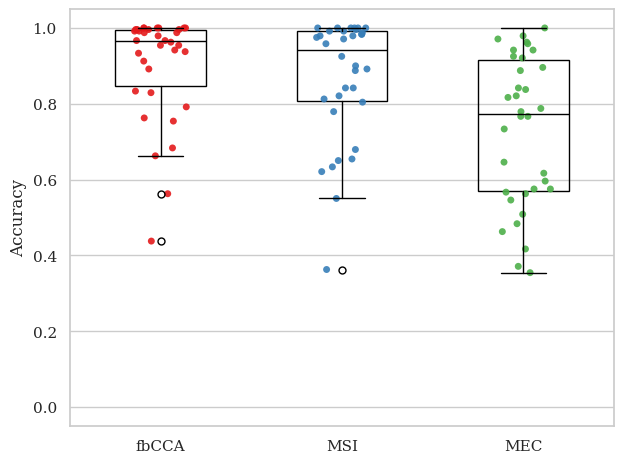

In [20]:
classifiers = ['fbCCA', 'MSI', 'MEC']
fig, ax = plt.subplots()

sns.boxplot(
    data = accuracy_df[classifiers],
    ax = ax,
    color = "black",
    boxprops=dict(facecolor='none'),
    flierprops = dict(
        marker='o',
        markersize=5,
        markerfacecolor="none",
        markeredgecolor='black',
        linestyle='none'
        ),
    width = 0.5,
    linewidth = 1   
)

sns.stripplot(
    data = accuracy_df[classifiers],
    ax = ax,
    jitter = 0.15,
    alpha = 0.9,
    zorder = 1,
    palette = "Set1",
)

ax.set_ylim(-0.05, 1.05) 
ax.set_ylabel("Accuracy")

plt.tight_layout() # Adjust the spacing between subplots
plt.show() # Show the plot